In [2]:
# Import the Libraries

import os
import random
import pandas as pd
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the dataset

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 284807
Number of columns: 31


In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [7]:
# Check missing values

missing_values = df.isnull().sum()
print("Total Missing Values:", missing_values.sum())


Total Missing Values: 0


In [8]:
# Check Duplicates

duplicate_count = df.duplicated().sum()
print("Total Duplicate Values:", duplicate_count)

Total Duplicate Values: 1081


In [9]:
# Check Target Distribution

print("Class Distribution")
print(df["Class"].value_counts())

Class Distribution
Class
0    284315
1       492
Name: count, dtype: int64


In [10]:
class_percentage = df["Class"].value_counts(normalize=True)*100

print("Class Percentage:")
print(class_percentage)

Class Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


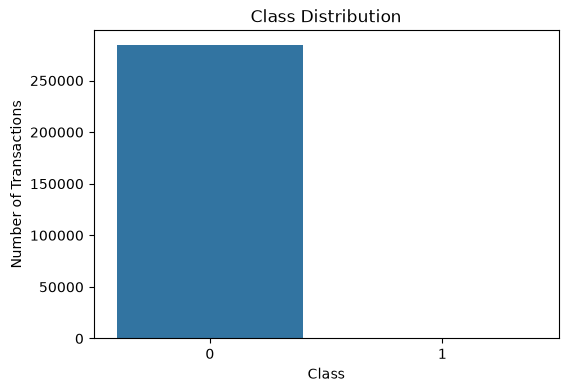

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [12]:
# Data Cleaning

# check duplicate count before removal

print("Duplicate rows before removel:", df.duplicated().sum())

# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)

# Check the new shape

print("Dataset shape after removing duplicates:", df.shape)

# Check duplicates again

print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows before removel: 1081
Dataset shape after removing duplicates: (283726, 31)
Duplicate rows after removal: 0


In [13]:
# Verify missing value again

print("Total missing values after cleaning:", df.isnull().sum().sum())

Total missing values after cleaning: 0


In [14]:
# Check the cleaned class distribution

print("Class Distribution After Cleaning:")
print(df["Class"].value_counts())

Class Distribution After Cleaning:
Class
0    283253
1       473
Name: count, dtype: int64


In [15]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

print("Class Percentage After Cleaning:")
print(class_percentage)

Class Percentage After Cleaning:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [16]:
# Verify data types

print(df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [17]:
# Exploratory Data Analysis

# statistical summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005934,1.948010,-56.407510,-0.915925,0.020316,1.316061,2.454930
V2,283726.0,-0.004127,1.646690,-72.715728,-0.600297,0.063942,0.800283,22.057729
V3,283726.0,0.016640,8.087261,-48.325589,-0.889682,0.179950,1.027007,4232.000000
V4,283726.0,-0.002943,1.414174,-5.683171,-0.850115,-0.022188,0.739690,16.875344
V5,283726.0,0.001850,1.376996,-113.743307,-0.689752,-0.053397,0.612218,34.801666
V6,283726.0,-0.001156,1.331903,-26.160506,-0.769026,-0.275132,0.396620,73.301626
V7,283726.0,0.001830,1.227646,-43.557242,-0.552476,0.040862,0.570493,120.589494
V8,283726.0,-0.000852,1.179056,-73.216718,-0.208828,0.021898,0.325716,20.007208
V9,283726.0,0.002731,2.540583,-13.434066,-0.644196,-0.052570,0.595977,1221.000000


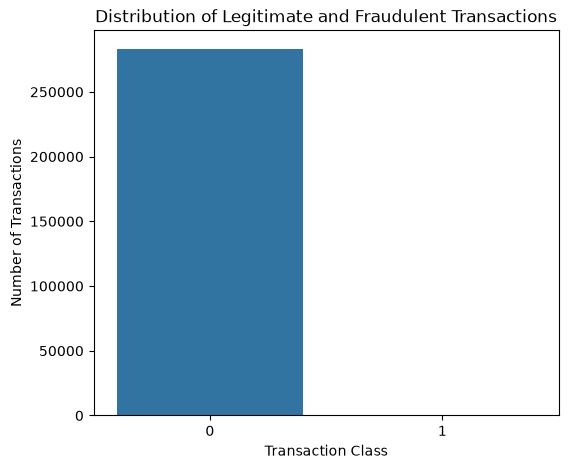

In [18]:
# Class Distribution

plt.figure(figsize=(6,5))

sns.countplot(
    x="Class",
    data=df
)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

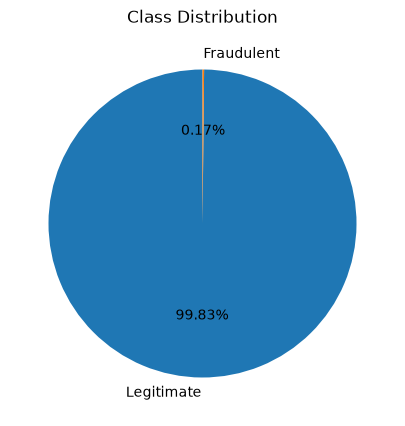

In [19]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(7, 5))

plt.pie(
    class_counts,
    labels=["Legitimate", "Fraudulent"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Class Distribution")

plt.show()



The target variable is highly imbalanced. Legitimate transactions represent approximately 99.83% of the cleaned dataset, while fraudulent transactions represent only about 0.17%. This severe class imbalance makes fraud detection challenging and means that accuracy alone will not be sufficient for evaluating the deep learning model. Precision, recall, F1-score and PR-AUC will therefore be important evaluation metrics.

In [20]:
# Transaction Amount Analysis

df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

In [21]:
# Skewness

print("Amount Skewness:", df["Amount"].skew())

Amount Skewness: 16.978803370060476


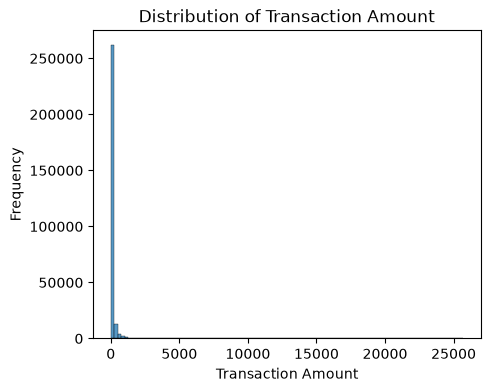

In [22]:
# Visualize the distribution

plt.figure(figsize=(5,4))

sns.histplot(
    data=df,
    x="Amount",
    bins=100,
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

Because Amount is highly right skewed, the normal histogram is not showing the smaller transaction values clearly.

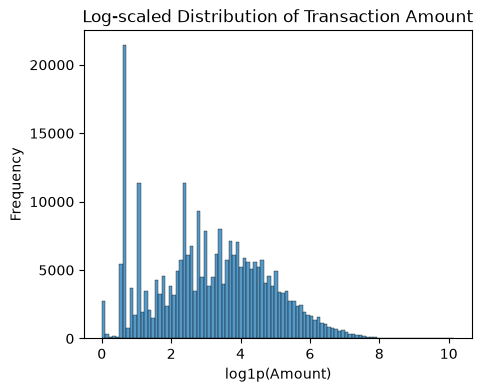

In [23]:
# Log scale visualization

plt.figure(figsize=(5,4))

sns.histplot(
    np.log1p(df["Amount"]),
    bins=100
)

plt.title("Log-scaled Distribution of Transaction Amount")
plt.xlabel("log1p(Amount)")
plt.ylabel("Frequency")

plt.show()

In [24]:
# Transaction Amount by Class

df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


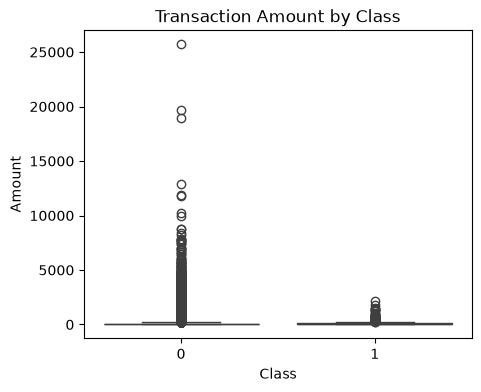

In [25]:
# Visualize using a Boxplot

plt.figure(figsize=(5,4))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

Because extreme values are dominationg the boxplot, so create another visualization using a logarithmic y axis 

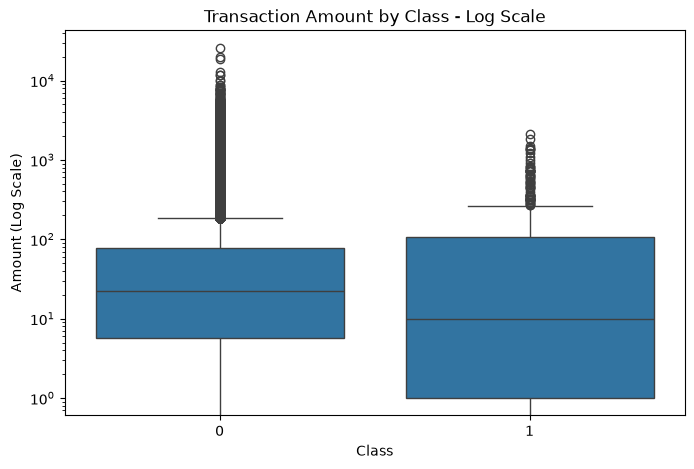

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.yscale("log")

plt.title("Transaction Amount by Class - Log Scale")
plt.xlabel("Class")
plt.ylabel("Amount (Log Scale)")

plt.show()



The transaction amount distribution is highly right-skewed, with a relatively small number of transactions having very large amounts. The class-wise distributions also show overlap between legitimate and fraudulent transactions. Therefore, transaction amount alone is not sufficient to distinguish fraudulent transactions.

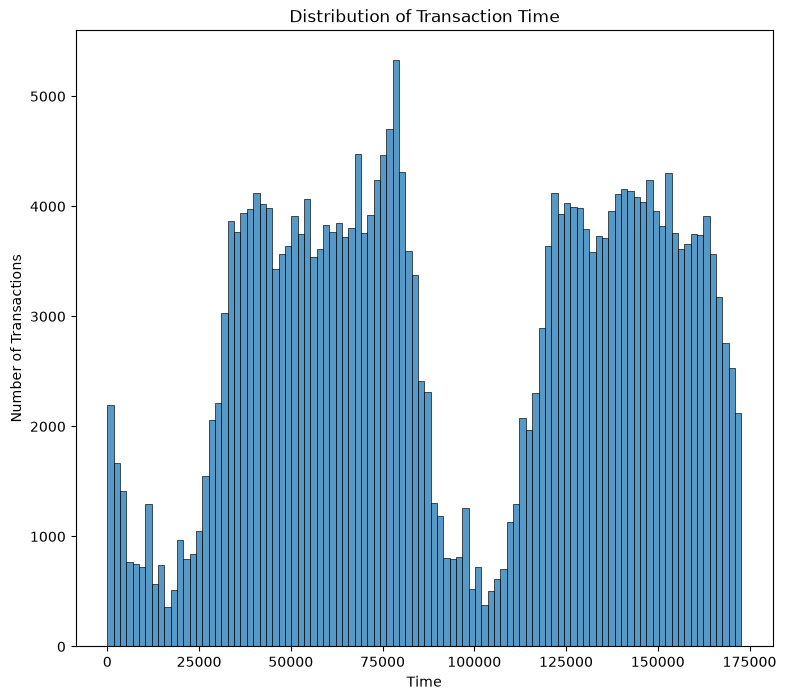

In [27]:
# Time Analysis

plt.figure(figsize=(9,8))

sns.histplot(
    data=df,
    x="Time",
    bins=100
)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

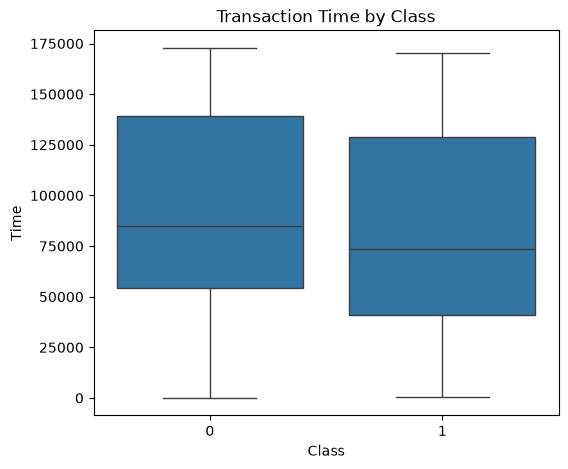

In [28]:
# Now compare the time across two classes

plt.figure(figsize=(6,5))

sns.boxplot(
    x="Class",
    y="Time",
    data=df
)

plt.title("Transaction Time by Class")
plt.xlabel("Class")
plt.ylabel("Time")

plt.show()



The Time variable has a non-uniform distribution, indicating that transactions are not evenly distributed throughout the recorded period. The class-wise distributions also show some differences between legitimate and fraudulent transactions. However, Time alone is not sufficient to identify fraudulent transactions.

In [29]:
# Feature Distribution Analysis

features = [f"V{i}" for i in range(1, 29)]

print(features)

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


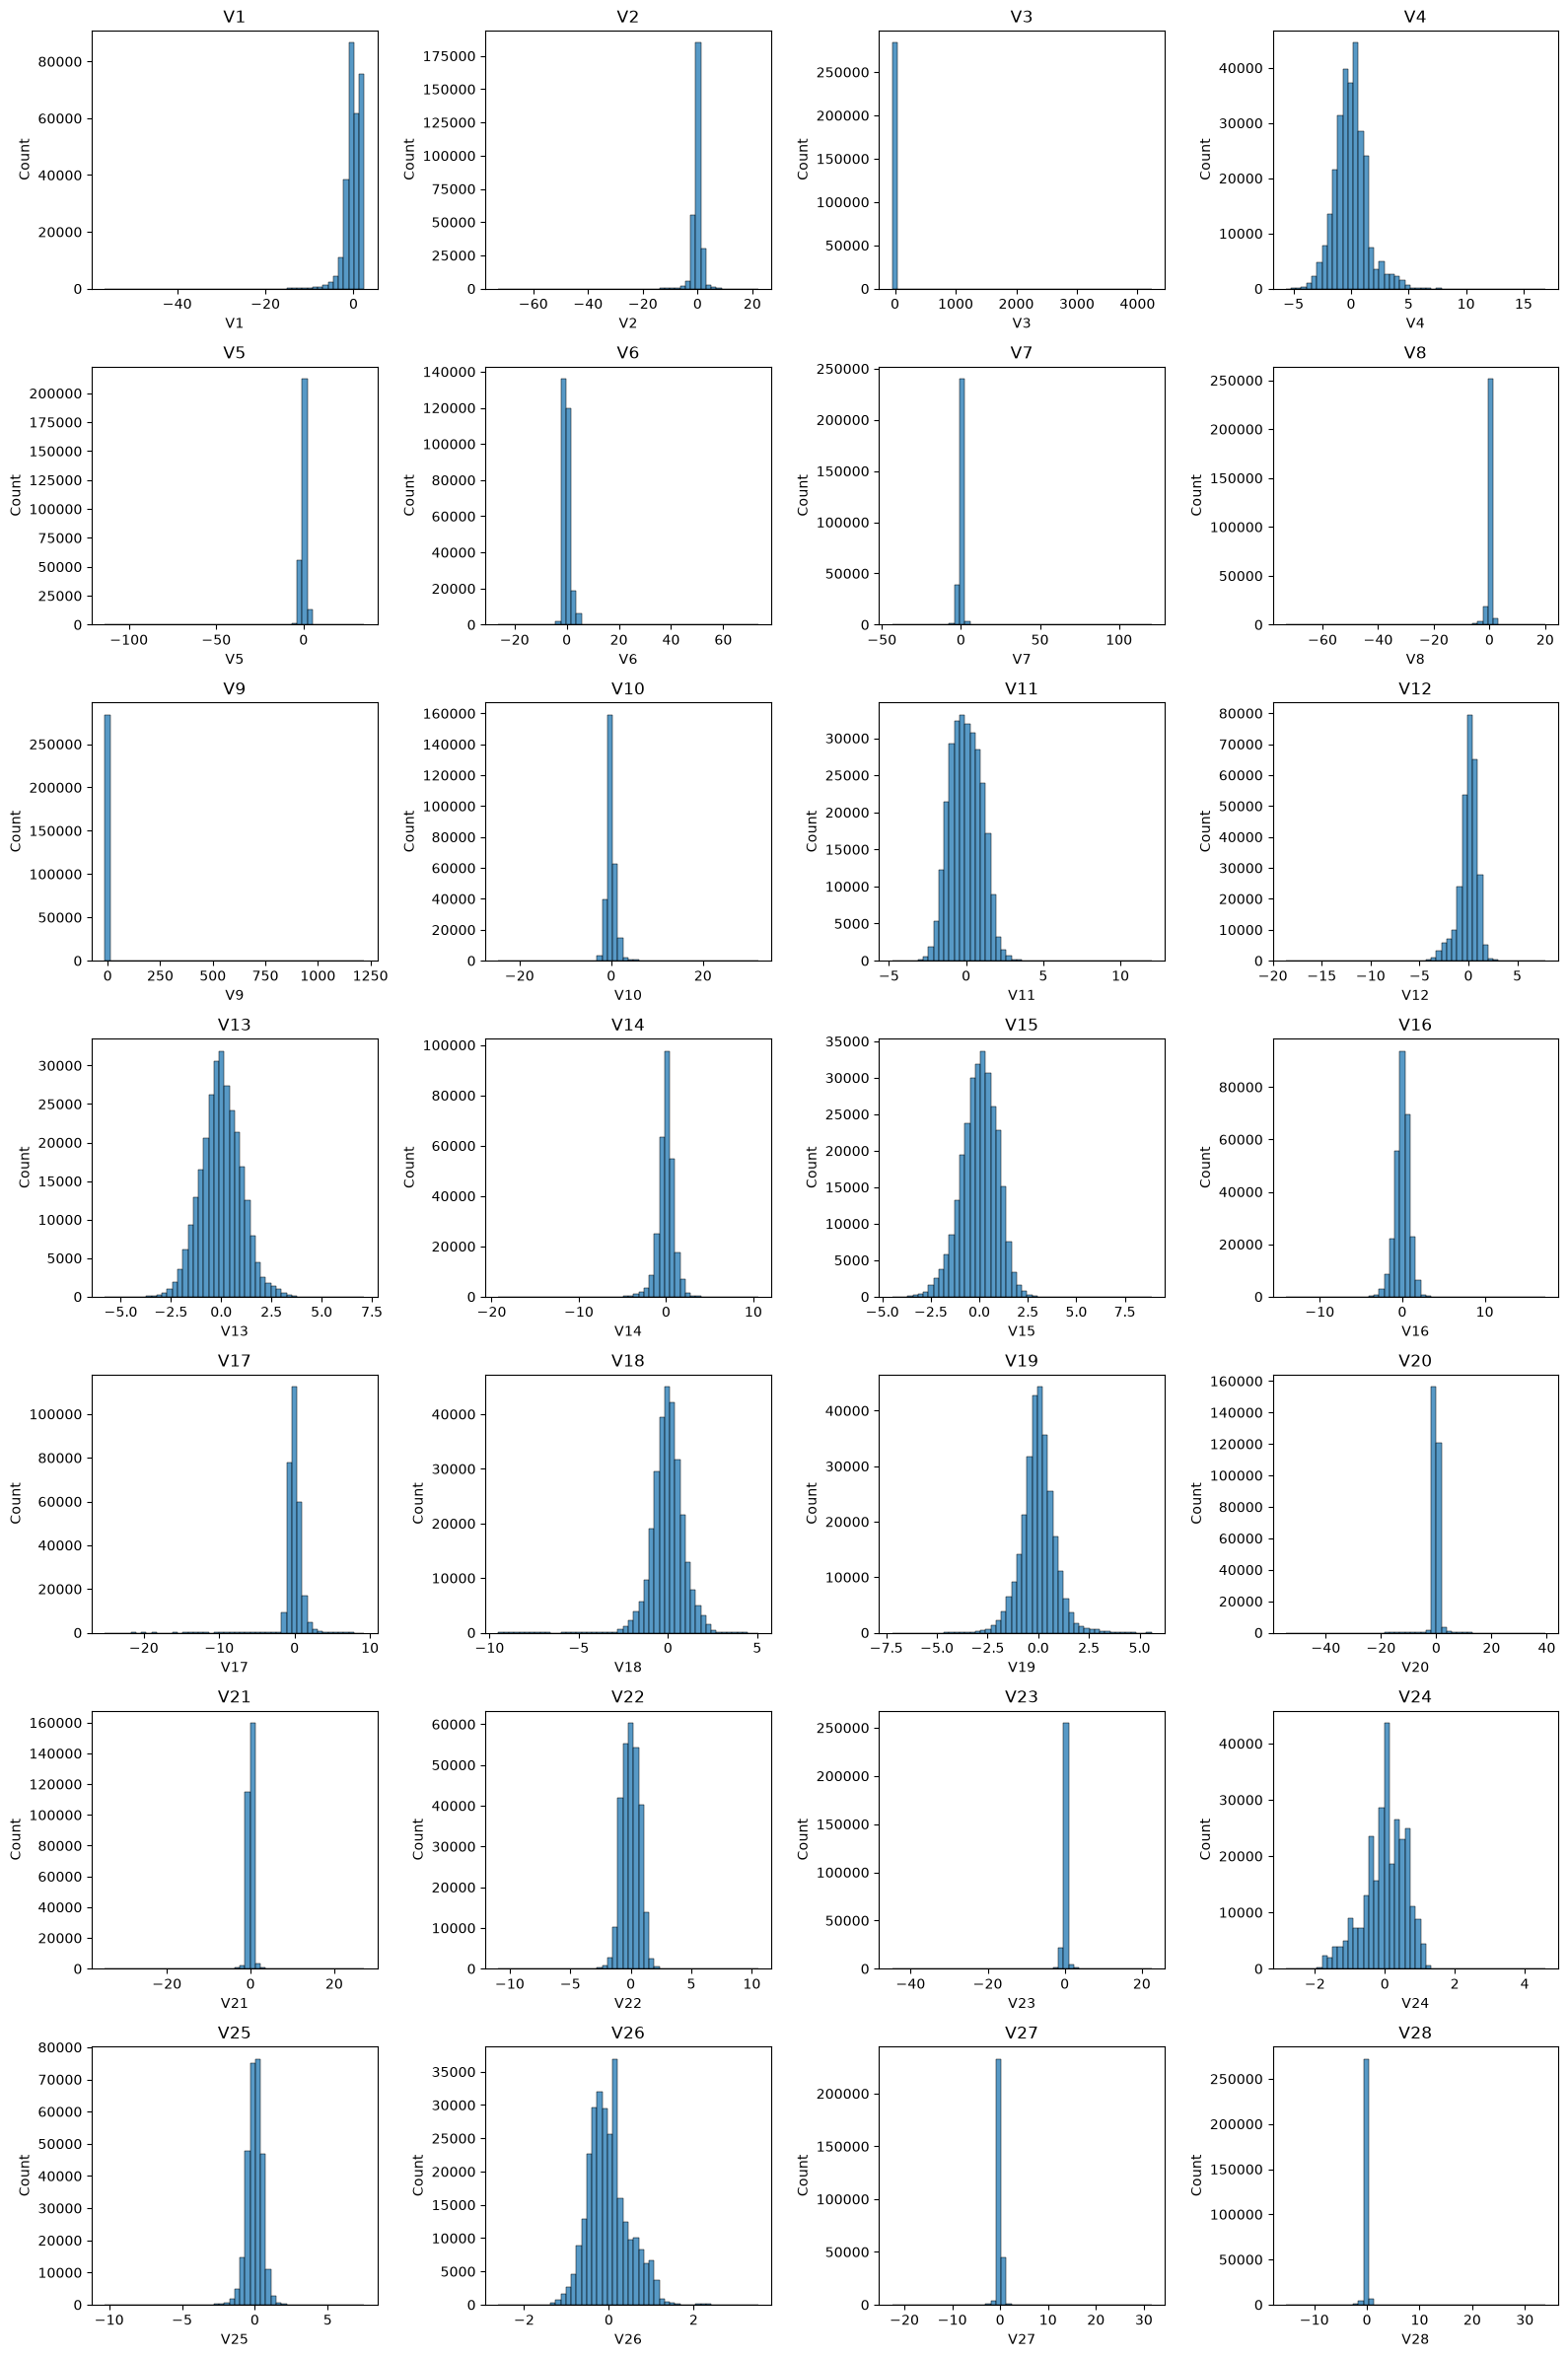

In [30]:
# Create distribution plot

fig, axes = plt.subplots(
    7,
    4,
    figsize=(16, 24)
)

for ax, feature in zip(axes.flatten(), features):
    sns.histplot(
        data=df,
        x=feature,
        bins=50,
        ax=ax
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

Let's compare the most relevant features between the two classes. from previous ML analysis, feature such as V14
V17, V12, V10, V16, V7 showed noticeable differences between the classes.



In [31]:
top_features = [
    "V14",
    "V17",
    "V12",
    "V10",
    "V16",
    "V7"
]

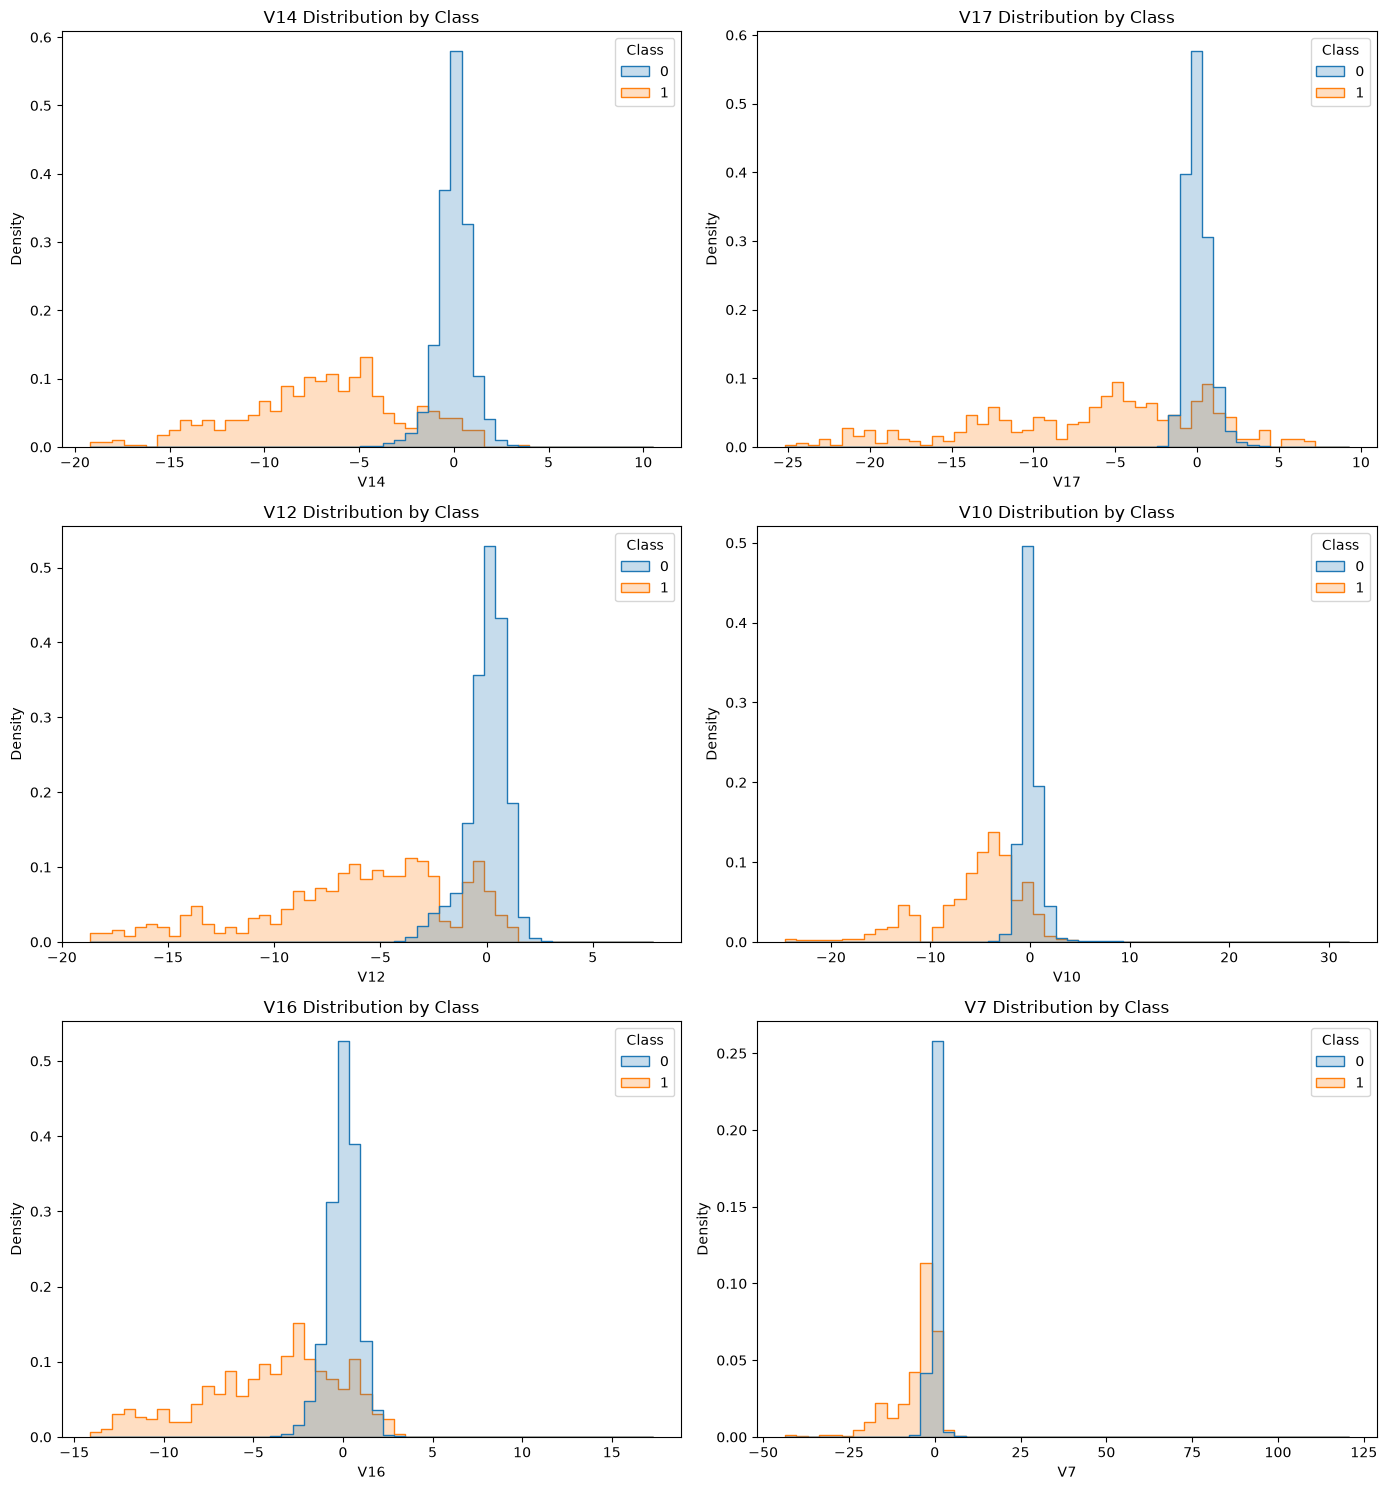

In [32]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 15)
)

for ax, feature in zip(axes.flatten(), top_features):
    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        bins=50,
        element="step",
        stat="density",
        common_norm=False,
        ax=ax
    )
    
    ax.set_title(f"{feature} Distribution by Class")

plt.tight_layout()
plt.show()

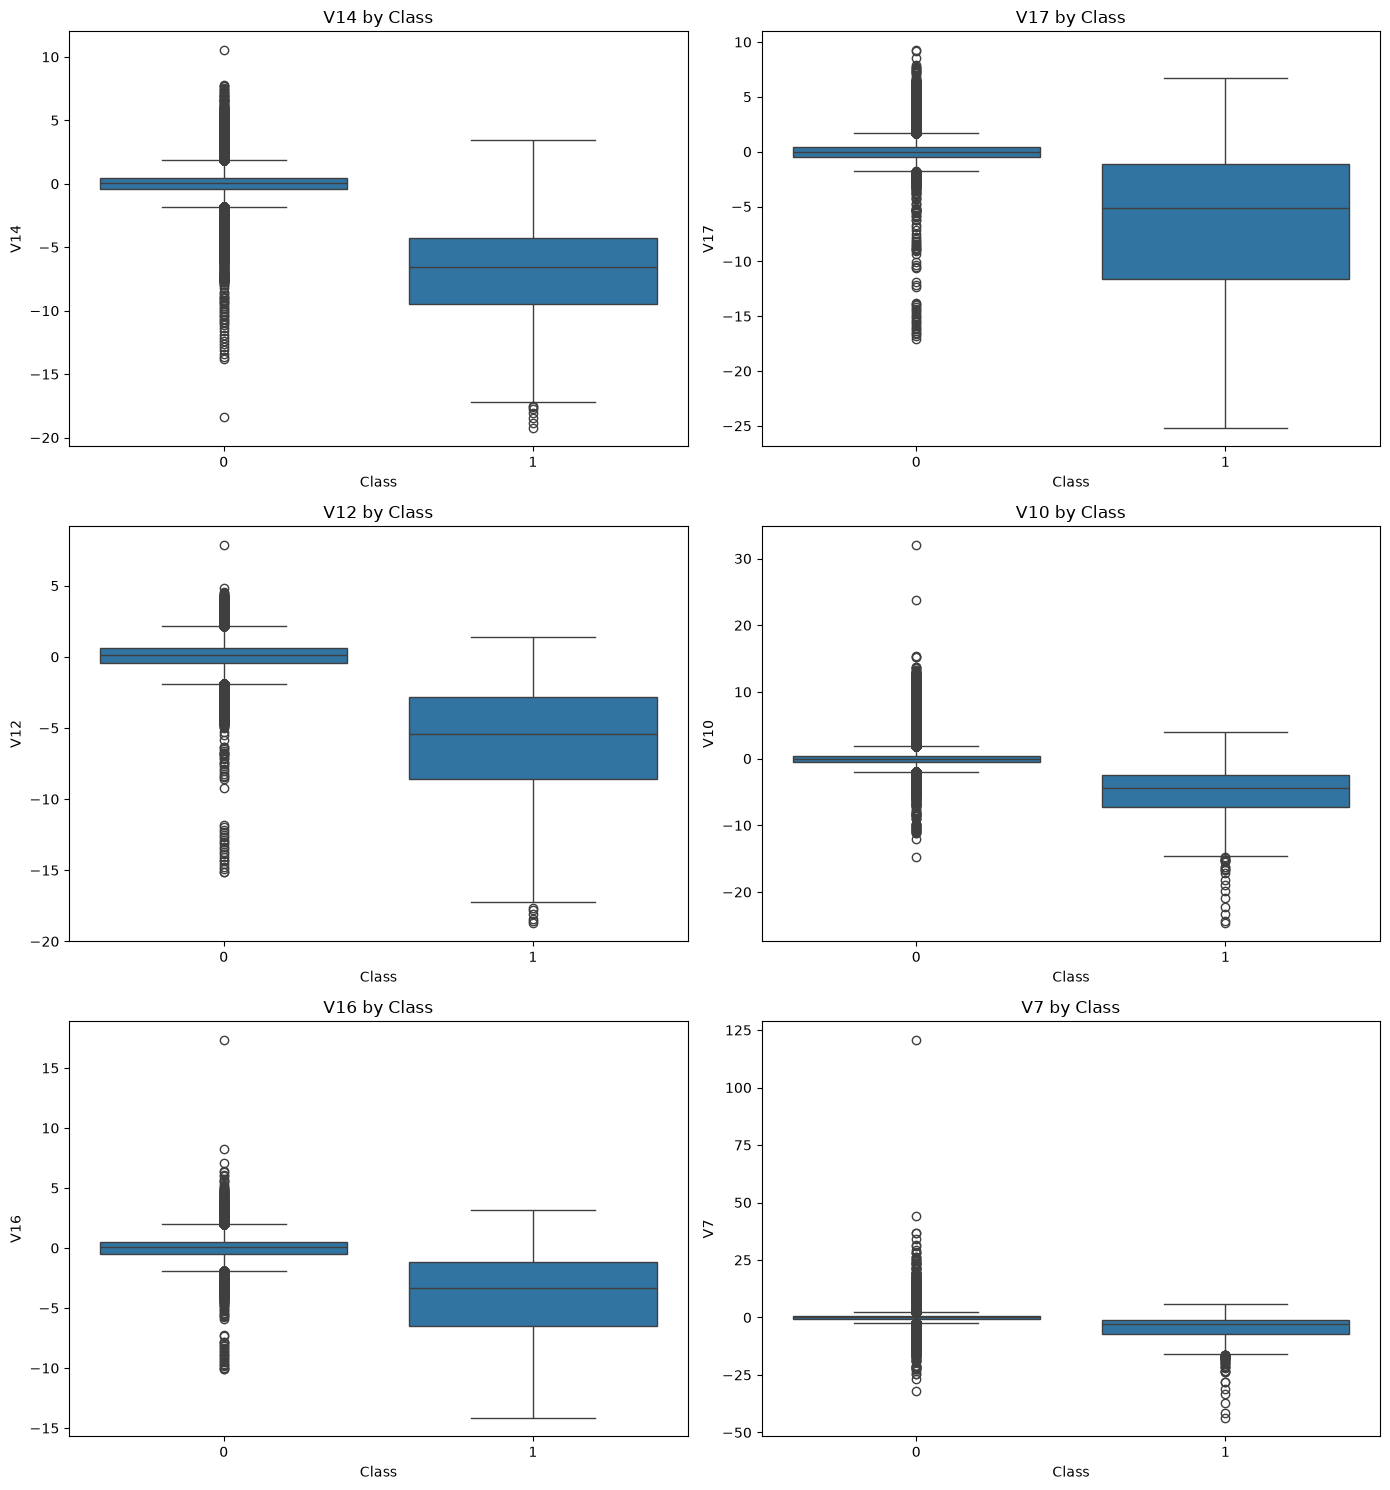

In [33]:
# Boxplot for important features

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 15)
)

for ax, feature in zip(axes.flatten(), top_features):
    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        ax=ax
    )
    
    ax.set_title(f"{feature} by Class")

plt.tight_layout()
plt.show()


Several anonymized PCA features show noticeable differences between legitimate and fraudulent transactions. Features such as V14, V17, V12, V10, V16 and V7 show visible shifts in their distributions across the two classes. However, the distributions also overlap considerably, indicating that fraud detection requires combining multiple features rather than relying on a single variable.

In [34]:
# Correlation Analysis

correlation_with_class = (
    df.corr(numeric_only=True)["Class"]
    .sort_values(key=abs, ascending=False)
)

print(correlation_with_class)

Class     1.000000
V17      -0.313498
V14      -0.293375
V12      -0.250713
V10      -0.206617
V16      -0.187186
V7       -0.172350
V11       0.149068
V4        0.129326
V18      -0.105340
V1       -0.094487
V5       -0.087814
V2        0.084625
V6       -0.043916
V9       -0.040611
V3       -0.034088
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
Time     -0.012359
V28       0.009682
V24      -0.007210
V23      -0.006333
Amount    0.005777
V22       0.004887
V26       0.004265
V13      -0.003897
V15      -0.003299
V25       0.003202
Name: Class, dtype: float64


In [35]:
correlation_with_class.head(15)

Class    1.000000
V17     -0.313498
V14     -0.293375
V12     -0.250713
V10     -0.206617
V16     -0.187186
V7      -0.172350
V11      0.149068
V4       0.129326
V18     -0.105340
V1      -0.094487
V5      -0.087814
V2       0.084625
V6      -0.043916
V9      -0.040611
Name: Class, dtype: float64

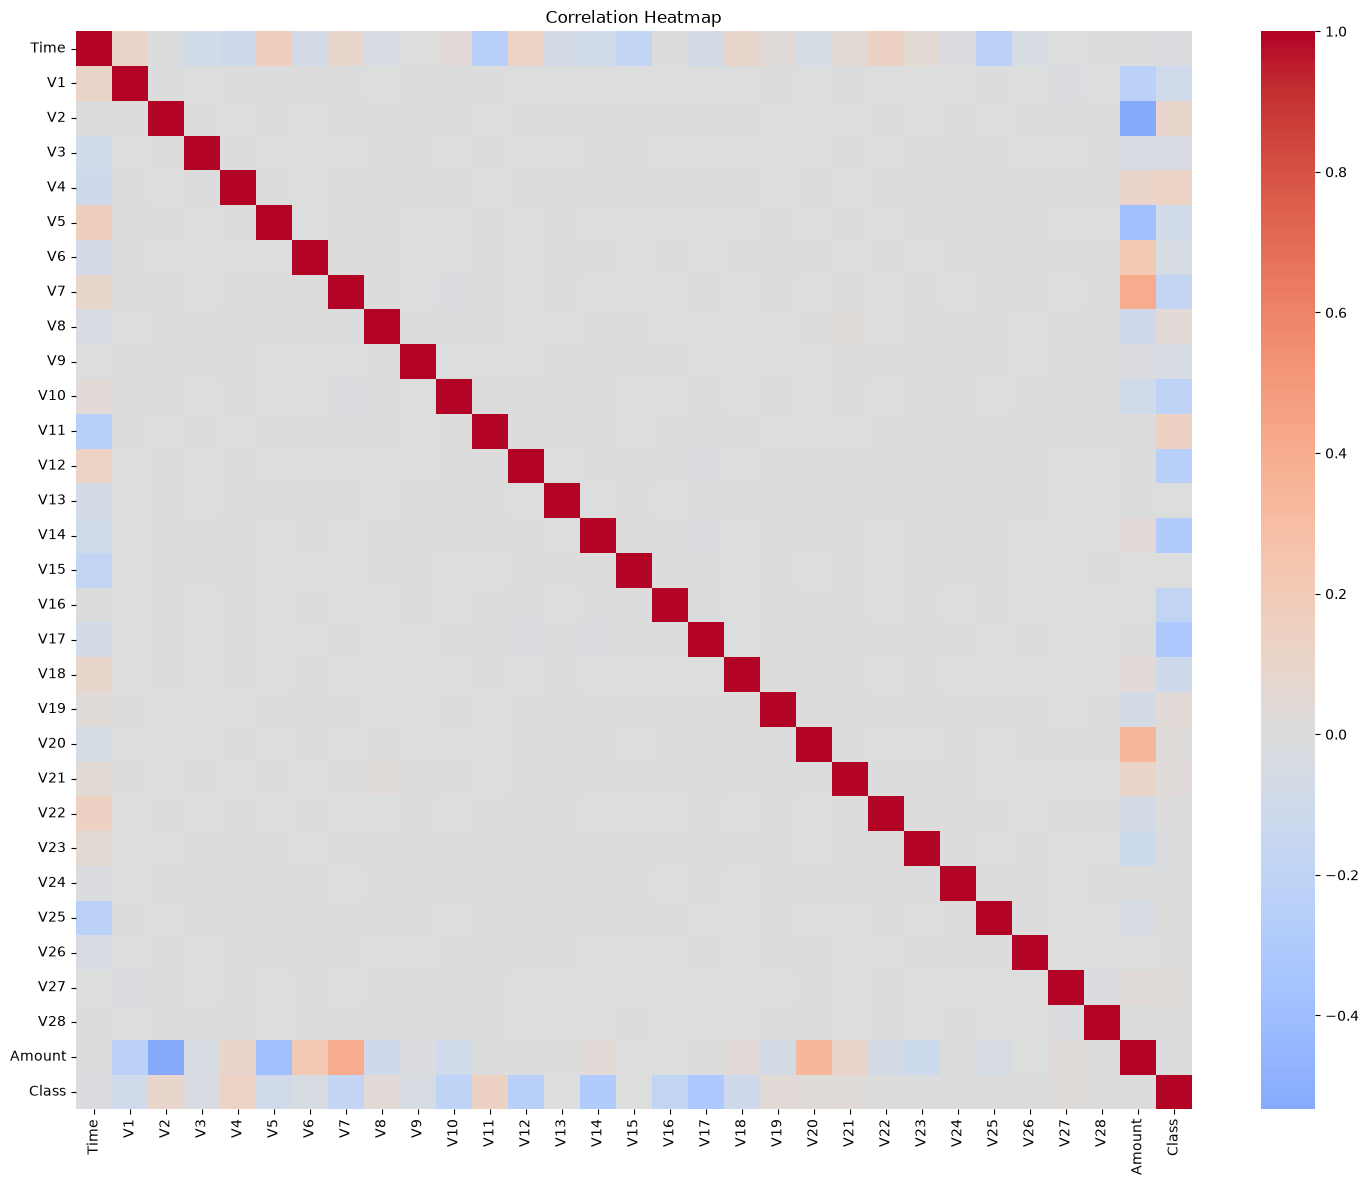

In [36]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()


The correlation analysis shows that several anonymized PCA features have stronger linear relationships with the target than others. V17, V14, V12, V10, V16 and V7 are among the features with relatively stronger absolute correlations with the fraud class. However, correlation measures linear relationships and does not represent model feature importance or causality.

In [37]:
# Outlier Analysis

feature_columns = df.drop(columns="Class").columns

outlier_counts = {}

for column in feature_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )
    
    outlier_counts[column] = outliers.sum()

outlier_counts = pd.Series(
    outlier_counts
).sort_values(ascending=False)

print(outlier_counts)

V27       38799
Amount    31685
V28       30094
V20       27553
V8        23902
V6        22887
V23       18467
V12       15283
V21       14401
V14       14060
V2        13390
V5        12221
V4        11094
V19       10150
V10        9349
V7         8838
V9         8199
V16        8180
V18        7468
V17        7353
V1         6949
V26        5665
V25        5333
V24        4758
V13        3362
V3         3307
V15        2885
V22        1298
V11         735
Time          0
dtype: int64


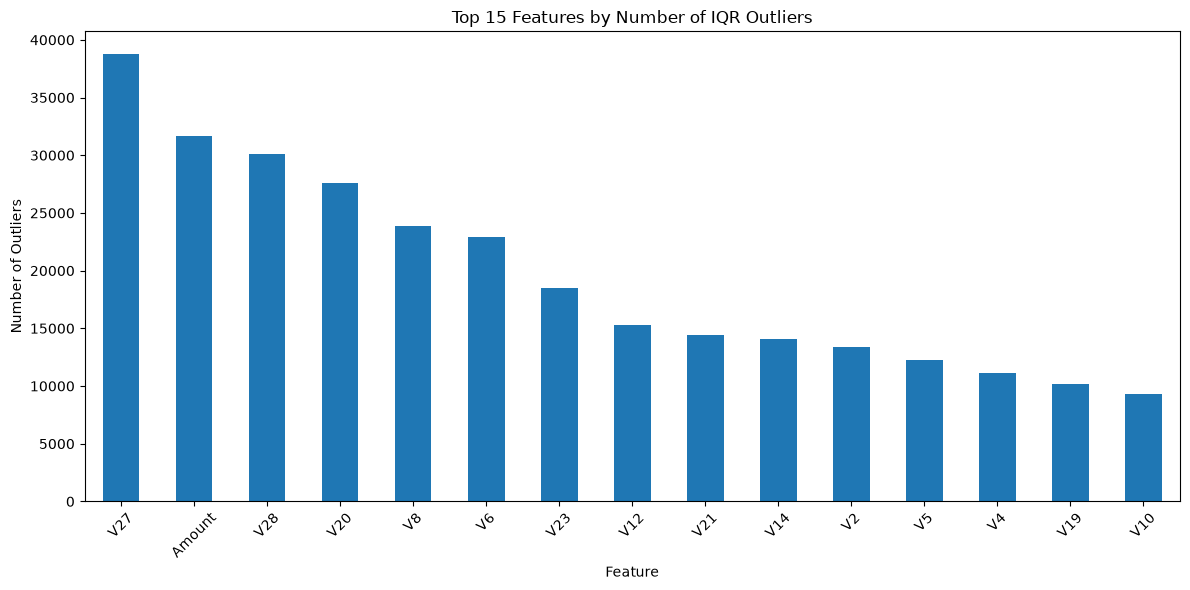

In [38]:
plt.figure(figsize=(12, 6))

outlier_counts.head(15).plot(
    kind="bar"
)

plt.title("Top 15 Features by Number of IQR Outliers")
plt.xlabel("Feature")
plt.ylabel("Number of Outliers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


The IQR analysis identified statistical outliers across several variables. However, these observations were retained because unusual transaction patterns may contain valuable information for fraud detection. Automatically removing these observations could potentially remove genuine fraudulent patterns.

## EDA Summary

The exploratory analysis provided the following insights:

- The cleaned dataset contains 283,726 transactions and 31 columns.
- There are no missing values.
- The target variable is highly imbalanced, with approximately 99.83% legitimate and 0.17% fraudulent transactions.
- The Amount feature is strongly right-skewed.
- The Time feature has a non-uniform distribution.
- Legitimate and fraudulent transactions show noticeable differences in the distributions of several anonymized PCA features.
- Features such as V14, V17, V12, V10, V16 and V7 show relatively strong differences between the two classes.
- Correlation analysis identified several features with stronger linear relationships with the target.
- Multiple statistical outliers were identified using the IQR method.
- Outliers were retained because unusual observations may contain useful fraud-related information.

These findings indicate that class imbalance, feature scaling and appropriate evaluation metrics will be important considerations when developing the deep learning model.

In [39]:
# Data Splitting & Preprocessing

# Separate features and target variable

X = df.drop(columns="Class")
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (283726, 30)
Target shape: (283726,)


In [40]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set shape: (226980, 30)
Test set shape: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [41]:
# Create validation set

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set shape: (181584, 30)
Validation set shape: (45396, 30)
Test set shape: (56746, 30)

Training class distribution:
Class
0    181282
1       302
Name: count, dtype: int64

Validation class distribution:
Class
0    45320
1       76
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [42]:
# Check class percentage

print("Training class percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation class percentage:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTest class percentage:")
print(y_test.value_counts(normalize=True) * 100)

Training class percentage:
Class
0    99.833686
1     0.166314
Name: proportion, dtype: float64

Validation class percentage:
Class
0    99.832584
1     0.167416
Name: proportion, dtype: float64

Test class percentage:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


In [43]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [44]:
scaler.fit_transform(X_train)
scaler.transform(X_val)
scaler.transform(X_test)

array([[-0.70801403,  0.62833789, -0.03403695, ...,  0.0031731 ,
         0.00383522, -0.31254219],
       [ 1.2741455 , -0.10580052,  0.71332411, ...,  0.96406307,
         0.79239882, -0.3513838 ],
       [-1.34853398, -0.85927027,  0.8486952 , ...,  0.01538857,
         0.34444661,  0.01159836],
       ...,
       [-0.44215054,  0.60364225, -0.11588604, ...,  0.02961053,
         0.07810382, -0.32213071],
       [ 0.68919106,  1.05500595,  0.08656072, ..., -0.1666381 ,
        -0.13396823, -0.35564988],
       [-1.76588615,  0.63772619,  0.04096458, ..., -0.21894052,
         0.02183495, -0.29446215]], shape=(56746, 30))

In [45]:
# Check the scaled data

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (181584, 30)
Scaled validation shape: (45396, 30)
Scaled test shape: (56746, 30)


In [46]:
# Check Mean and Standard Deviation

print("Training feature means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining feature standard deviations:")
print(X_train_scaled.std(axis=0))

Training feature means:
[ 7.52474712e-17 -2.03477301e-17 -5.32171403e-18 -4.22606702e-18
  2.35564106e-17  1.12695121e-17  2.17564191e-17  9.23473905e-18
 -1.25216801e-18  4.38258803e-18 -1.65912261e-17 -1.56521001e-17
 -7.51300804e-18 -2.69216122e-17 -1.67477471e-17 -1.11129911e-17
  1.61216631e-17 -8.13909205e-18 -1.37738481e-17 -1.29129826e-17
 -5.63475603e-18 -1.14260331e-17  2.59042257e-17 -1.25216801e-18
  1.53390581e-17 -1.51042766e-17  1.81564361e-17  1.87825201e-18
 -1.87825201e-18 -3.13042002e-18]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [47]:
# Convert Target to numpy arrays

y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

y_train shape: (181584,)
y_val shape: (45396,)
y_test shape: (56746,)


In [48]:
# Check the final data

print("X_train:", X_train_scaled.shape)
print("X_val:", X_val_scaled.shape)
print("X_test:", X_test_scaled.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print("\nTraining fraud cases:", (y_train == 1).sum())
print("Validation fraud cases:", (y_val == 1).sum())
print("Test fraud cases:", (y_test == 1).sum())

X_train: (181584, 30)
X_val: (45396, 30)
X_test: (56746, 30)
y_train: (181584,)
y_val: (45396,)
y_test: (56746,)

Training fraud cases: 302
Validation fraud cases: 76
Test fraud cases: 95


## Observation

The cleaned dataset was divided into training, validation and test sets using stratified sampling to preserve the highly imbalanced class distribution. Standardization was then applied to the numerical features using StandardScaler. The scaler was fitted only on the training data and subsequently used to transform the validation and test sets, preventing data leakage. All 30 available features were retained for the ANN model. Due to the severe class imbalance, class weighting will be used during model training rather than relying on accuracy as the primary evaluation criterion.

In [49]:
# Class Imbalance and Baseline ANN

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights_array))

print("Class weights:")
print(class_weights)

Class weights:
{np.int64(0): np.float64(0.5008329563883893), np.int64(1): np.float64(300.63576158940396)}


In [50]:
# Verify the class weights

print(f"Weight for Class 0 (Legitimate): {class_weights[0]:.4f}")
print(f"Weight for Class 1 (Fraud): {class_weights[1]:.4f}")

Weight for Class 0 (Legitimate): 0.5008
Weight for Class 1 (Fraud): 300.6358


The calculated class weights assign substantially greater importance to fraudulent transactions because they represent only a very small proportion of the training data. Class weighting allows the ANN to account for the severe class imbalance during optimization without modifying the validation or test datasets.

In [51]:
# Build the baseline ANN

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(64, activation="relu"),
    Dropout(0.30),

    Dense(32, activation="relu"),
    Dropout(0.20),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

In [52]:
# Display the Model Architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Compile the ANN

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="roc_auc"),
        AUC(name="pr_auc", curve="PR")
    ]
)

In [54]:
# Add Callbacks

early_stopping = EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_pr_auc",
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [55]:
# Train the baseline ANN

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/30
710/710 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9503 - loss: 0.3094 - pr_auc: 0.6011 - precision: 0.0272 - recall: 0.8311 - roc_auc: 0.9157 - val_accuracy: 0.9908 - val_loss: 0.0978 - val_pr_auc: 0.7791 - val_precision: 0.1414 - val_recall: 0.8816 - val_roc_auc: 0.9702 - learning_rate: 0.0010
Epoch 2/30
710/710 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9699 - loss: 0.2065 - pr_auc: 0.6193 - precision: 0.0478 - recall: 0.9040 - roc_auc: 0.9647 - val_accuracy: 0.9842 - val_loss: 0.0760 - val_pr_auc: 0.7684 - val_precision: 0.0875 - val_recall: 0.8947 - val_roc_auc: 0.9769 - learning_rate: 0.0010
Epoch 3/30
695/710 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9689 - loss: 0.1549 - pr_auc: 0.6017 - precision: 0.0474 - recall: 0.9133 - roc_auc: 0.9831
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
710/710 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9692 - loss: 0.1527 - pr_auc: 0.5985 - precision: 0.0472 - recall: 0.9139 - roc_auc: 0.

In [56]:
# Check Training history

print("Training epochs completed:", len(history.history["loss"]))

Training epochs completed: 6


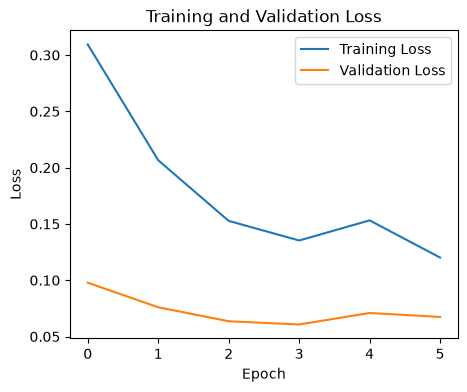

In [57]:
# Plot Training and Validation Loss

plt.figure(figsize=(5,4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

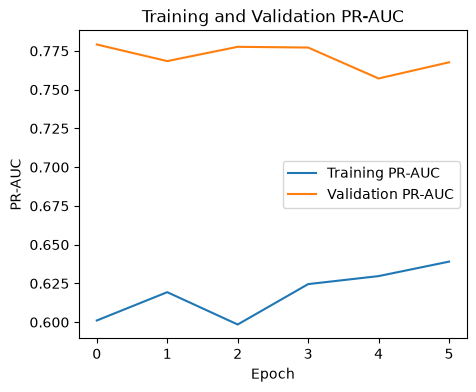

In [58]:
# Plot PR-AUC

plt.figure(figsize=(5,4))

plt.plot(history.history["pr_auc"], label="Training PR-AUC")
plt.plot(history.history["val_pr_auc"], label="Validation PR-AUC")

plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("Training and Validation PR-AUC")
plt.legend()

plt.show()

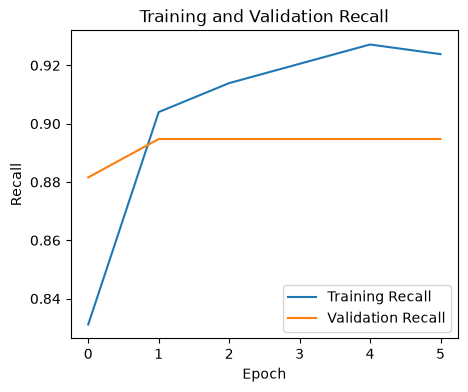

In [59]:
# Plot Recall

plt.figure(figsize=(5,4))

plt.plot(history.history["recall"], label="Training Recall")
plt.plot(history.history["val_recall"], label="Validation Recall")

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Training and Validation Recall")
plt.legend()

plt.show()

In [60]:
# Evaluate the model on validation data

val_results = model.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

for metric_name, metric_value in zip(model.metrics_names, val_results):
    print(f"{metric_name}: {metric_value:.4f}")

loss: 0.0978
compile_metrics: 0.9908


In [61]:
# Probability based evaluation & threshold optimization

y_val_prob = model.predict(X_val_scaled).ravel()

1419/1419 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [62]:
print("Minimum probability:", y_val_prob.min())
print("Maximum probability:", y_val_prob.max())
print("Mean probability:", y_val_prob.mean())

Minimum probability: 4.058208e-15
Maximum probability: 1.0
Mean probability: 0.086260416


In [63]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(4))

    Threshold  Precision  Recall  F1-Score
0        0.10     0.0058  0.9342    0.0116
1        0.15     0.0121  0.9211    0.0239
2        0.20     0.0240  0.9211    0.0469
3        0.25     0.0407  0.9211    0.0780
4        0.30     0.0602  0.9079    0.1128
5        0.35     0.0804  0.8947    0.1475
6        0.40     0.0997  0.8947    0.1794
7        0.45     0.1193  0.8947    0.2105
8        0.50     0.1414  0.8816    0.2436
9        0.55     0.1599  0.8816    0.2707
10       0.60     0.1846  0.8816    0.3052
11       0.65     0.2359  0.8816    0.3722
12       0.70     0.3436  0.8816    0.4945
13       0.75     0.6000  0.8684    0.7097
14       0.80     0.7021  0.8684    0.7765
15       0.85     0.7500  0.8684    0.8049
16       0.90     0.7952  0.8684    0.8302


In [64]:
thresholds_fine = np.arange(0.80, 1.001, 0.01)

fine_results = []

for threshold in thresholds_fine:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)

    fine_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

fine_threshold_df = pd.DataFrame(fine_results)

print(fine_threshold_df.round(4))

    Threshold  Precision  Recall  F1-Score
0        0.80     0.7021  0.8684    0.7765
1        0.81     0.7174  0.8684    0.7857
2        0.82     0.7333  0.8684    0.7952
3        0.83     0.7333  0.8684    0.7952
4        0.84     0.7333  0.8684    0.7952
5        0.85     0.7500  0.8684    0.8049
6        0.86     0.7586  0.8684    0.8098
7        0.87     0.7674  0.8684    0.8148
8        0.88     0.7765  0.8684    0.8199
9        0.89     0.7952  0.8684    0.8302
10       0.90     0.7952  0.8684    0.8302
11       0.91     0.7927  0.8553    0.8228
12       0.92     0.7927  0.8553    0.8228
13       0.93     0.7927  0.8553    0.8228
14       0.94     0.8025  0.8553    0.8280
15       0.95     0.8333  0.8553    0.8442
16       0.96     0.8667  0.8553    0.8609
17       0.97     0.8667  0.8553    0.8609
18       0.98     0.8649  0.8421    0.8533
19       0.99     0.8767  0.8421    0.8591
20       1.00     0.0000  0.0000    0.0000


In [65]:
best_threshold_row = fine_threshold_df.loc[
    fine_threshold_df["F1-Score"].idxmax()
]

print("Best threshold based on validation F1-score:")
print(best_threshold_row)

Best threshold based on validation F1-score:
Threshold    0.960000
Precision    0.866667
Recall       0.855263
F1-Score     0.860927
Name: 16, dtype: float64


In [66]:
# Final ANN Evaluation on Test Data

# Generate test probabilities

y_test_prob = model.predict(X_test_scaled).ravel()

print("Number of test probabilities:", len(y_test_prob))

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Number of test probabilities: 56746


In [67]:
# Apply the selected threshold

best_threshold = 0.99

y_test_pred = (y_test_prob >= best_threshold).astype(int)

print("Test predictions generated.")
print("Fraud predictions:", y_test_pred.sum())

Test predictions generated.
Fraud predictions: 81


In [68]:
# Calculate test metrics

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

test_roc_auc = roc_auc_score(y_test, y_test_prob)
test_pr_auc = average_precision_score(y_test, y_test_prob)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")
print(f"PR-AUC   : {test_pr_auc:.4f}")

Accuracy : 0.9994
Precision: 0.8765
Recall   : 0.7474
F1-Score : 0.8068
ROC-AUC  : 0.9403
PR-AUC   : 0.6647


In [69]:
# Confusion Metrics

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[56641    10]
 [   24    71]]


In [70]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9996    0.9998    0.9997     56651
       Fraud     0.8765    0.7474    0.8068        95

    accuracy                         0.9994     56746
   macro avg     0.9381    0.8736    0.9033     56746
weighted avg     0.9994    0.9994    0.9994     56746



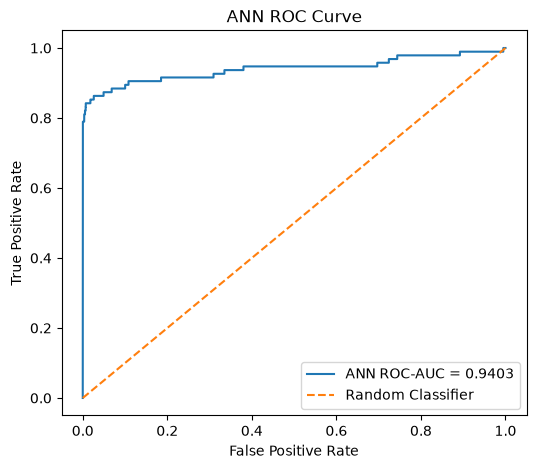

In [71]:
# ROC-Curve

from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"ANN ROC-AUC = {test_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ANN ROC Curve")
plt.legend()

plt.show()

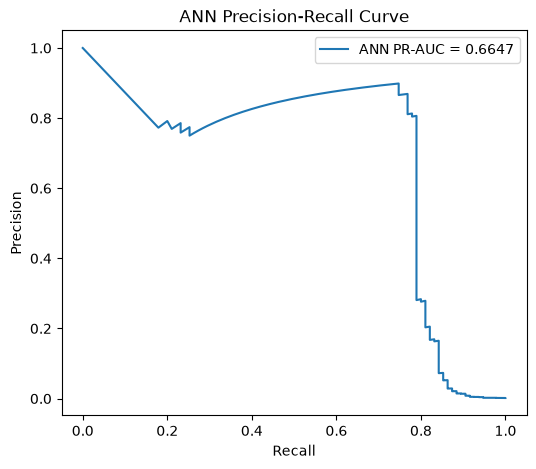

In [72]:
# Precision Recall Curve

from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"ANN PR-AUC = {test_pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("ANN Precision-Recall Curve")
plt.legend()

plt.show()

In [73]:
# Save the ANN

model.save("fraud_detection_ann.keras")

print("ANN model saved successfully.")

ANN model saved successfully.


In [74]:
# Save the scaler

import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


In [75]:
# Save feature columns

feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

print("Feature columns saved successfully.")
print(feature_columns)

Feature columns saved successfully.
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [76]:
# Save the threshold

best_threshold = 0.99

joblib.dump(best_threshold, "threshold.pkl")

print("Threshold saved successfully.")
print("Saved threshold:", best_threshold)

Threshold saved successfully.
Saved threshold: 0.99


In [77]:
# Verifying all files

import os 

files_to_check = [
    "fraud_detection_ann.keras",
    "scaler.pkl",
    "feature_columns.pkl",
    "threshold.pkl"
]

for file in files_to_check:
    if os.path.exists(file):
        print(f"✓ {file} exists")
    else:
        print(f"✗ {file} NOT FOUND")

✓ fraud_detection_ann.keras exists
✓ scaler.pkl exists
✓ feature_columns.pkl exists
✓ threshold.pkl exists


In [78]:
# Test that the saved artifacts can be loaded

loaded_model = load_model("fraud_detection_ann.keras")

print("Model loaded successfully.")

Model loaded successfully.


In [79]:
# Load the scaler

loaded_scaler = joblib.load("scaler.pkl")

print("Scaler loaded successfully.")

Scaler loaded successfully.


In [80]:
# Load the feature columns

loaded_feature_columns = joblib.load("feature_columns.pkl")

print("Feature columns loaded successfully.")
print(loaded_feature_columns)

Feature columns loaded successfully.
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [81]:
# Load threshold

loaded_threshold = joblib.load("threshold.pkl")

print("Threshold loaded successfully:", loaded_threshold)

Threshold loaded successfully: 0.99


In [82]:
# Verify the loaded model

sample_predictions = loaded_model.predict(
    X_test_scaled[:5]
).ravel()

print("Sample fraud probabilities:")
print(sample_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Sample fraud probabilities:
[0.08554276 0.0860303  0.06414682 0.07493737 0.21785073]


In [83]:
# Verify the complete Prediction Pipeline

sample_raw = X_test.iloc[:5].copy()

print(sample_raw)

            Time        V1        V2        V3        V4        V5        V6  \
86249    61290.0  1.228821 -0.063408  0.274145  0.647465 -0.048135  0.372073   
250634  155394.0 -0.203154  1.176678 -0.759595 -0.518472  0.629649 -0.721675   
20163    30881.0 -1.672836  1.401297  1.503940  2.175491  0.699791  1.062139   
68688    53203.0  0.819379 -1.124913  0.515025  0.513945 -1.009048  0.488484   
191151  129429.0  2.009701  0.105635 -1.752759  0.588312  0.374801 -0.637884   

              V7        V8        V9  ...       V20       V21       V22  \
86249  -0.224231  0.079939  0.640759  ... -0.096566 -0.129554 -0.083779   
250634  0.638893  0.243377 -0.157488  ... -0.098429  0.384629  1.206754   
20163   1.114364 -0.535822 -0.252983  ...  0.828472 -0.525950 -0.408743   
68688  -0.580672  0.187686 -0.999142  ... -0.110144 -0.057205 -0.168061   
191151  0.009260 -0.129487  0.492619  ... -0.135479  0.008970  0.357394   

             V23       V24       V25       V26       V27       V28  

In [84]:
sample_scaled = loaded_scaler.transform(sample_raw)

In [85]:
sample_probabilities = loaded_model.predict(sample_scaled).ravel()

sample_predictions = (
    sample_probabilities >= loaded_threshold
).astype(int)

print("Fraud probabilities:")
print(sample_probabilities)

print("\nPredicted classes:")
print(sample_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Fraud probabilities:
[0.08554276 0.0860303  0.06414682 0.07493737 0.21785073]

Predicted classes:
[0 0 0 0 0]


## Summary

The trained ANN and all preprocessing components required for deployment were saved. The model was saved in Keras format, while the StandardScaler, feature column order and classification threshold were saved using Joblib. Saving these artifacts ensures that new transactions can undergo the same preprocessing and prediction procedure used during model development. The saved artifacts were also reloaded and tested to verify that the deployment pipeline can reproduce ANN predictions.

### Improved ANN with Batch Normalization

In [86]:
# Build the improved ANN

tuned_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.20),

    Dense(32, activation="relu"),
    Dropout(0.10),

    Dense(1, activation="sigmoid")
])

In [87]:
# Check the Architecture

tuned_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [88]:
# Compile the Improved ANN

tuned_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="roc_auc"),
        AUC(name="pr_auc", curve="PR")
    ]
)

In [89]:
# Use the same callbacks
tuned_early_stopping = EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

tuned_reduce_lr = ReduceLROnPlateau(
    monitor="val_pr_auc",
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


In [90]:
# Train the Improved ANN

tuned_history = tuned_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[
        tuned_early_stopping,
        tuned_reduce_lr
    ],
    verbose=1
)

Epoch 1/30
710/710 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8920 - loss: 0.3201 - pr_auc: 0.4215 - precision: 0.0131 - recall: 0.8609 - roc_auc: 0.9240 - val_accuracy: 0.9782 - val_loss: 0.1716 - val_pr_auc: 0.7673 - val_precision: 0.0641 - val_recall: 0.8816 - val_roc_auc: 0.9583 - learning_rate: 5.0000e-04
Epoch 2/30
710/710 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9513 - loss: 0.1794 - pr_auc: 0.5354 - precision: 0.0303 - recall: 0.9139 - roc_auc: 0.9780 - val_accuracy: 0.9785 - val_loss: 0.1140 - val_pr_auc: 0.7194 - val_precision: 0.0649 - val_recall: 0.8816 - val_roc_auc: 0.9684 - learning_rate: 5.0000e-04
Epoch 3/30
709/710 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9575 - loss: 0.1453 - pr_auc: 0.5691 - precision: 0.0350 - recall: 0.9238 - roc_auc: 0.9858
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
710/710 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9575 - loss: 0.1453 - pr_auc: 0.5691 - precision: 0.0350 - recall: 0.9238 - ro

In [91]:
# Check Training Duration

print(
    "Tuned ANN training epochs:",
    len(tuned_history.history["loss"])
)

Tuned ANN training epochs: 7


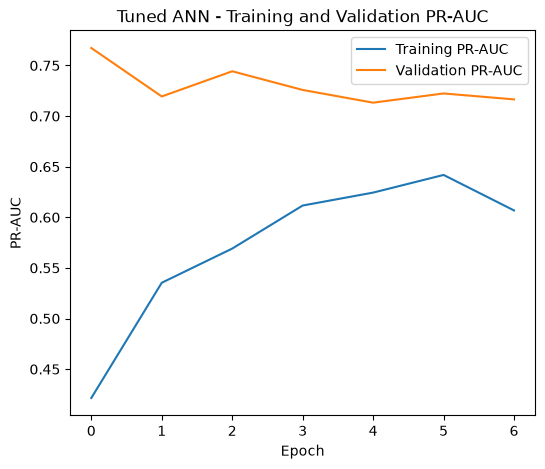

In [92]:
# Plot Training/Validation PR-AUC

plt.figure(figsize=(6,5))

plt.plot(
    tuned_history.history["pr_auc"],
    label="Training PR-AUC"
)

plt.plot(
    tuned_history.history["val_pr_auc"],
    label="Validation PR-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("Tuned ANN - Training and Validation PR-AUC")
plt.legend()

plt.show()

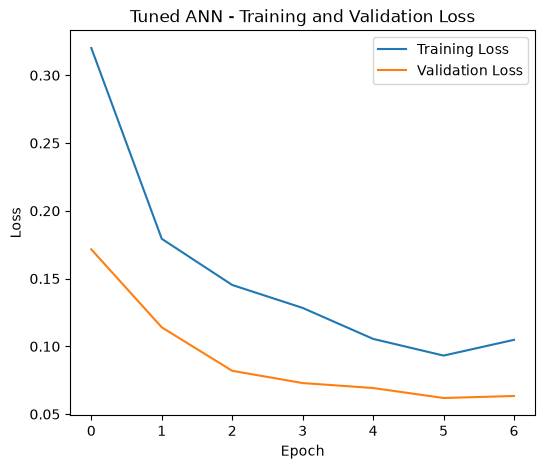

In [93]:
# Plot Loss

plt.figure(figsize=(6,5))

plt.plot(
    tuned_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    tuned_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Tuned ANN - Training and Validation Loss")
plt.legend()

plt.show()

In [94]:
# First Comparison - Validation Performance

tuned_val_prob = tuned_model.predict(
    X_val_scaled
).ravel()

1419/1419 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [95]:
tuned_val_roc_auc = roc_auc_score(
    y_val,
    tuned_val_prob
)

tuned_val_pr_auc = average_precision_score(
    y_val,
    tuned_val_prob
)

print(f"Tuned ANN Validation ROC-AUC: {tuned_val_roc_auc:.4f}")
print(f"Tuned ANN Validation PR-AUC : {tuned_val_pr_auc:.4f}")

Tuned ANN Validation ROC-AUC: 0.9582
Tuned ANN Validation PR-AUC : 0.7850


In [96]:
# Optimize the Tuned ANN Threshold

tuned_thresholds = np.arange(0.80, 1.001, 0.01)

tuned_threshold_results = []

for threshold in tuned_thresholds:

    y_val_pred = (
        tuned_val_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    tuned_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

tuned_threshold_df = pd.DataFrame(
    tuned_threshold_results
)

print(tuned_threshold_df.round(4))

    Threshold  Precision  Recall  F1-Score
0        0.80     0.3300  0.8684    0.4783
1        0.81     0.3474  0.8684    0.4962
2        0.82     0.3729  0.8684    0.5217
3        0.83     0.3976  0.8684    0.5455
4        0.84     0.4371  0.8684    0.5815
5        0.85     0.4615  0.8684    0.6027
6        0.86     0.5156  0.8684    0.6471
7        0.87     0.5641  0.8684    0.6839
8        0.88     0.5789  0.8684    0.6947
9        0.89     0.6000  0.8684    0.7097
10       0.90     0.6168  0.8684    0.7213
11       0.91     0.6408  0.8684    0.7374
12       0.92     0.6535  0.8684    0.7458
13       0.93     0.7065  0.8553    0.7738
14       0.94     0.7303  0.8553    0.7879
15       0.95     0.7303  0.8553    0.7879
16       0.96     0.7647  0.8553    0.8075
17       0.97     0.7590  0.8289    0.7925
18       0.98     0.7683  0.8289    0.7975
19       0.99     0.8676  0.7763    0.8194
20       1.00     0.0000  0.0000    0.0000


In [97]:
best_tuned_threshold_row = tuned_threshold_df.loc[
    tuned_threshold_df["F1-Score"].idxmax()
]

print("Best tuned ANN threshold:")
print(best_tuned_threshold_row)

Best tuned ANN threshold:
Threshold    0.990000
Precision    0.867647
Recall       0.776316
F1-Score     0.819444
Name: 19, dtype: float64


In [98]:
# Tuned ANN Test Probabilities

tuned_test_prob = tuned_model.predict(
    X_test_scaled
).ravel()

print("Number of tuned ANN test probabilities:", len(tuned_test_prob))

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Number of tuned ANN test probabilities: 56746


In [99]:
# Apply the validation selected threshold

best_tuned_threshold = 0.99

tuned_test_pred = (tuned_test_prob >= best_tuned_threshold).astype(int)

print("Tuned ANN test predictions generated.")

print("Fraud Prediction:", tuned_test_pred.sum())

Tuned ANN test predictions generated.
Fraud Prediction: 80


In [100]:
# Calculate Final Tuned ANN Metrics

tuned_test_accuracy = accuracy_score(
    y_test,
    tuned_test_pred
)

tuned_test_precision = precision_score(
    y_test,
    tuned_test_pred,
    zero_division=0
)

tuned_test_recall = recall_score(
    y_test,
    tuned_test_pred,
    zero_division=0
)

tuned_test_f1 = f1_score(
    y_test,
    tuned_test_pred,
    zero_division=0
)

tuned_test_roc_auc = roc_auc_score(
    y_test,
    tuned_test_prob
)

tuned_test_pr_auc = average_precision_score(
    y_test,
    tuned_test_prob
)

print(f"Accuracy : {tuned_test_accuracy:.4f}")
print(f"Precision: {tuned_test_precision:.4f}")
print(f"Recall   : {tuned_test_recall:.4f}")
print(f"F1-Score : {tuned_test_f1:.4f}")
print(f"ROC-AUC  : {tuned_test_roc_auc:.4f}")
print(f"PR-AUC   : {tuned_test_pr_auc:.4f}")

Accuracy : 0.9992
Precision: 0.8250
Recall   : 0.6947
F1-Score : 0.7543
ROC-AUC  : 0.9635
PR-AUC   : 0.6293


In [101]:
# Tuned ANN Confusion Matrix

tuned_cm = confusion_matrix(
    y_test,
    tuned_test_pred
)

print("Tuned ANN Confusion Matrix:")
print(tuned_cm)

tn, fp, fn, tp = tuned_cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Tuned ANN Confusion Matrix:
[[56637    14]
 [   29    66]]

True Negatives : 56637
False Positives: 14
False Negatives: 29
True Positives : 66


In [102]:
# Tuned ANN Classification Report

print(
    classification_report(
        y_test,
        tuned_test_pred,
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9995    0.9998    0.9996     56651
       Fraud     0.8250    0.6947    0.7543        95

    accuracy                         0.9992     56746
   macro avg     0.9122    0.8472    0.8770     56746
weighted avg     0.9992    0.9992    0.9992     56746



In [103]:
# Calculate metrics automatically

comparison_ann = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    
    "Baseline ANN": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_prob),
        average_precision_score(y_test, y_test_prob)
    ],
    
    "Tuned ANN": [
        accuracy_score(y_test, tuned_test_pred),
        precision_score(y_test, tuned_test_pred),
        recall_score(y_test, tuned_test_pred),
        f1_score(y_test, tuned_test_pred),
        roc_auc_score(y_test, tuned_test_prob),
        average_precision_score(y_test, tuned_test_prob)
    ]
})

# Display rounded values
comparison_ann.round(4)

,Metric,Baseline ANN,Tuned ANN
0,Accuracy,0.9994,0.9992
1,Precision,0.8765,0.8250
2,Recall,0.7474,0.6947
3,F1-Score,0.8068,0.7543
4,ROC-AUC,0.9403,0.9635
5,PR-AUC,0.6647,0.6293


In [104]:
# Save the final tuned model and deployment files

tuned_model.save("fraud_detection_ann_tuned.keras")

# Save preprocessing artifacts

joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

# Save the threshold selected using validation data

joblib.dump(best_tuned_threshold, "threshold.pkl")

print("Final DL deployment files saved successfully.")



Final DL deployment files saved successfully.


In [105]:

files_to_check = [
    "fraud_detection_ann_tuned.keras",
    "scaler.pkl",
    "feature_columns.pkl",
    "threshold.pkl"
]

for file in files_to_check:
    print(f"{file}: {'Found' if os.path.exists(file) else 'Missing'}")

fraud_detection_ann_tuned.keras: Found
scaler.pkl: Found
feature_columns.pkl: Found
threshold.pkl: Found


In [106]:
# Verify the final saved tuned ANN pipeline

# Load final deployment artifacts
final_model = load_model("fraud_detection_ann_tuned.keras")
final_scaler = joblib.load("scaler.pkl")
final_feature_columns = joblib.load("feature_columns.pkl")
final_threshold = joblib.load("threshold.pkl")

print("Model loaded successfully")
print("Scaler loaded successfully")
print("Feature columns loaded successfully")
print("Threshold:", final_threshold)
print("Number of features:", len(final_feature_columns))

Model loaded successfully
Scaler loaded successfully
Feature columns loaded successfully
Threshold: 0.99
Number of features: 30


In [107]:
# Take a few raw test transactions
sample_data = X_test.iloc[:10].copy()

# Make sure the feature order is exactly the same as during training
sample_data = sample_data[final_feature_columns]

# Scale using the saved scaler
sample_scaled = final_scaler.transform(sample_data)

# Generate fraud probabilities
sample_probabilities = final_model.predict(
    sample_scaled,
    verbose=0
).ravel()

# Apply saved threshold
sample_predictions = (
    sample_probabilities >= final_threshold
).astype(int)

# Create result table
sample_results = pd.DataFrame({
    "Actual Class": y_test[:10],
    "Fraud Probability": sample_probabilities,
    "Predicted Class": sample_predictions
})

sample_results

,Actual Class,Fraud Probability,Predicted Class
0,0,0.097954,0
1,0,0.052673,0
2,0,0.123119,0
3,0,0.068836,0
4,0,0.423068,0
5,0,0.057288,0
6,0,0.085870,0
7,0,0.138061,0
8,0,0.111402,0
9,0,0.088606,0


In [108]:
# Scale the complete test set using the saved scaler
X_test_scaled_loaded = final_scaler.transform(
    X_test[final_feature_columns]
)

# Generate probabilities
loaded_test_prob = final_model.predict(
    X_test_scaled_loaded,
    verbose=0
).ravel()

# Apply saved threshold
loaded_test_pred = (
    loaded_test_prob >= final_threshold
).astype(int)

# Compare predictions
predictions_match = np.array_equal(
    tuned_test_pred,
    loaded_test_pred
)

print("Do original and loaded model predictions match?")
print(predictions_match)

Do original and loaded model predictions match?
True


In [109]:
# Check the saved model's final metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

final_accuracy = accuracy_score(y_test, loaded_test_pred)
final_precision = precision_score(y_test, loaded_test_pred)
final_recall = recall_score(y_test, loaded_test_pred)
final_f1 = f1_score(y_test, loaded_test_pred)
final_roc_auc = roc_auc_score(y_test, loaded_test_prob)
final_pr_auc = average_precision_score(y_test, loaded_test_prob)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")
print(f"PR-AUC   : {final_pr_auc:.4f}")

Accuracy : 0.9992
Precision: 0.8250
Recall   : 0.6947
F1-Score : 0.7543
ROC-AUC  : 0.9635
PR-AUC   : 0.6293


In [112]:
# Verify the existing Baseline ANN saved model

# Load the existing Baseline ANN artifacts
baseline_model_loaded = load_model("fraud_detection_ann.keras")
baseline_scaler_loaded = joblib.load("scaler.pkl")
baseline_features_loaded = joblib.load("feature_columns.pkl")
baseline_threshold_loaded = joblib.load("threshold.pkl")

print("Baseline ANN model loaded successfully")
print("Scaler loaded successfully")
print("Feature columns loaded successfully")
print("Threshold:", baseline_threshold_loaded)
print("Number of features:", len(baseline_features_loaded))

Baseline ANN model loaded successfully
Scaler loaded successfully
Feature columns loaded successfully
Threshold: 0.99
Number of features: 30


In [113]:
# test the complete saved model

# Prepare test data using the saved feature order
X_test_saved = X_test[baseline_features_loaded]

# Scale using the saved scaler
X_test_saved_scaled = baseline_scaler_loaded.transform(X_test_saved)

# Generate fraud probabilities
baseline_loaded_prob = baseline_model_loaded.predict(
    X_test_saved_scaled,
    verbose=0
).ravel()

# Apply the saved threshold
baseline_loaded_pred = (
    baseline_loaded_prob >= baseline_threshold_loaded
).astype(int)

# Check whether predictions match the original Baseline ANN
predictions_match = np.array_equal(
    y_test_pred,
    baseline_loaded_pred
)

print("Do original and loaded Baseline ANN predictions match?")
print(predictions_match)

Do original and loaded Baseline ANN predictions match?
True


Based on the test-set comparison, the Baseline ANN was selected as the final model because it achieved higher Accuracy, Precision, Recall, F1-Score, and PR-AUC than the Tuned ANN.